In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/telecom_churn_clean.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


LOADING DATA:dataset contains both numerical and categorical variables
             it includes customer details like tenure,charges,churn

In [ ]:
# Get a concise summary of the DataFrame, including data types and non-null values
df.info()

# Display descriptive statistics for numerical columns
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              3333 non-null   int64  
 1   account_length          3333 non-null   int64  
 2   area_code               3333 non-null   int64  
 3   international_plan      3333 non-null   int64  
 4   voice_mail_plan         3333 non-null   int64  
 5   number_vmail_messages   3333 non-null   int64  
 6   total_day_minutes       3333 non-null   float64
 7   total_day_calls         3333 non-null   int64  
 8   total_day_charge        3333 non-null   float64
 9   total_eve_minutes       3333 non-null   float64
 10  total_eve_calls         3333 non-null   int64  
 11  total_eve_charge        3333 non-null   float64
 12  total_night_minutes     3333 non-null   float64
 13  total_night_calls       3333 non-null   int64  
 14  total_night_charge      3333 non-null   

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
count,3333.00000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,1666.00000,101.064806,437.182418,0.096910,0.276628,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856,0.144914
std,962.29855,39.822106,42.371290,0.295879,0.447398,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491,0.352067
min,0.00000,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,833.00000,74.000000,408.000000,0.000000,0.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000,0.000000
50%,1666.00000,101.000000,415.000000,0.000000,0.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000,0.000000
75%,2499.00000,127.000000,510.000000,0.000000,1.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000,0.000000
max,3332.00000,243.000000,510.000000,1.000000,1.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000


In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
display(missing_values[missing_values > 0])


Missing values in each column:


,0


MISSING VALUES:
some columns contain missing values.
total charges may have null or incorrect entries.



### Outlier Identification using Box Plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for outlier detection
numeric_cols = df.select_dtypes(include=['number']).columns

# Create box plots for numerical columns to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 4, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Outlier Identification using IQR Method

This method identifies outliers as values that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

In [ ]:
import pandas as pd

def detect_iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Ensure numeric_cols is defined within this cell for standalone execution
numeric_cols = df.select_dtypes(include=['number']).columns

print("Outliers detected using IQR method:")
for col in numeric_cols:
    outliers = detect_iqr_outliers(df, col)
    if not outliers.empty:
        print(f"\nColumn: {col}")
        display(outliers[[col]].head())
    else:
        print(f"\nNo outliers detected for column: {col}")

Outliers detected using IQR method:

No outliers detected for column: Unnamed: 0

Column: account_length


,account_length
197,208
238,215
309,209
416,224
817,243



No outliers detected for column: area_code

Column: international_plan


,international_plan
3,1
4,1
5,1
7,1
9,1



No outliers detected for column: voice_mail_plan

Column: number_vmail_messages


...

,total_intl_charge
115,5.40
179,0.00
214,4.75
225,0.73
314,5.10



Column: customer_service_calls


,customer_service_calls
10,4
14,4
15,4
21,5
48,5



Column: churn


,churn
10,1
15,1
21,1
33,1
41,1


OUTLIER IDENTIFICATION:
outliers are present in numerical columns.
they appear as extreme values in boxplots.
duplicate rows are removed to improve data quality.

### Univariate Analysis: Distributions of Individual Features


--- Histograms and KDE plots for Numerical Features ---


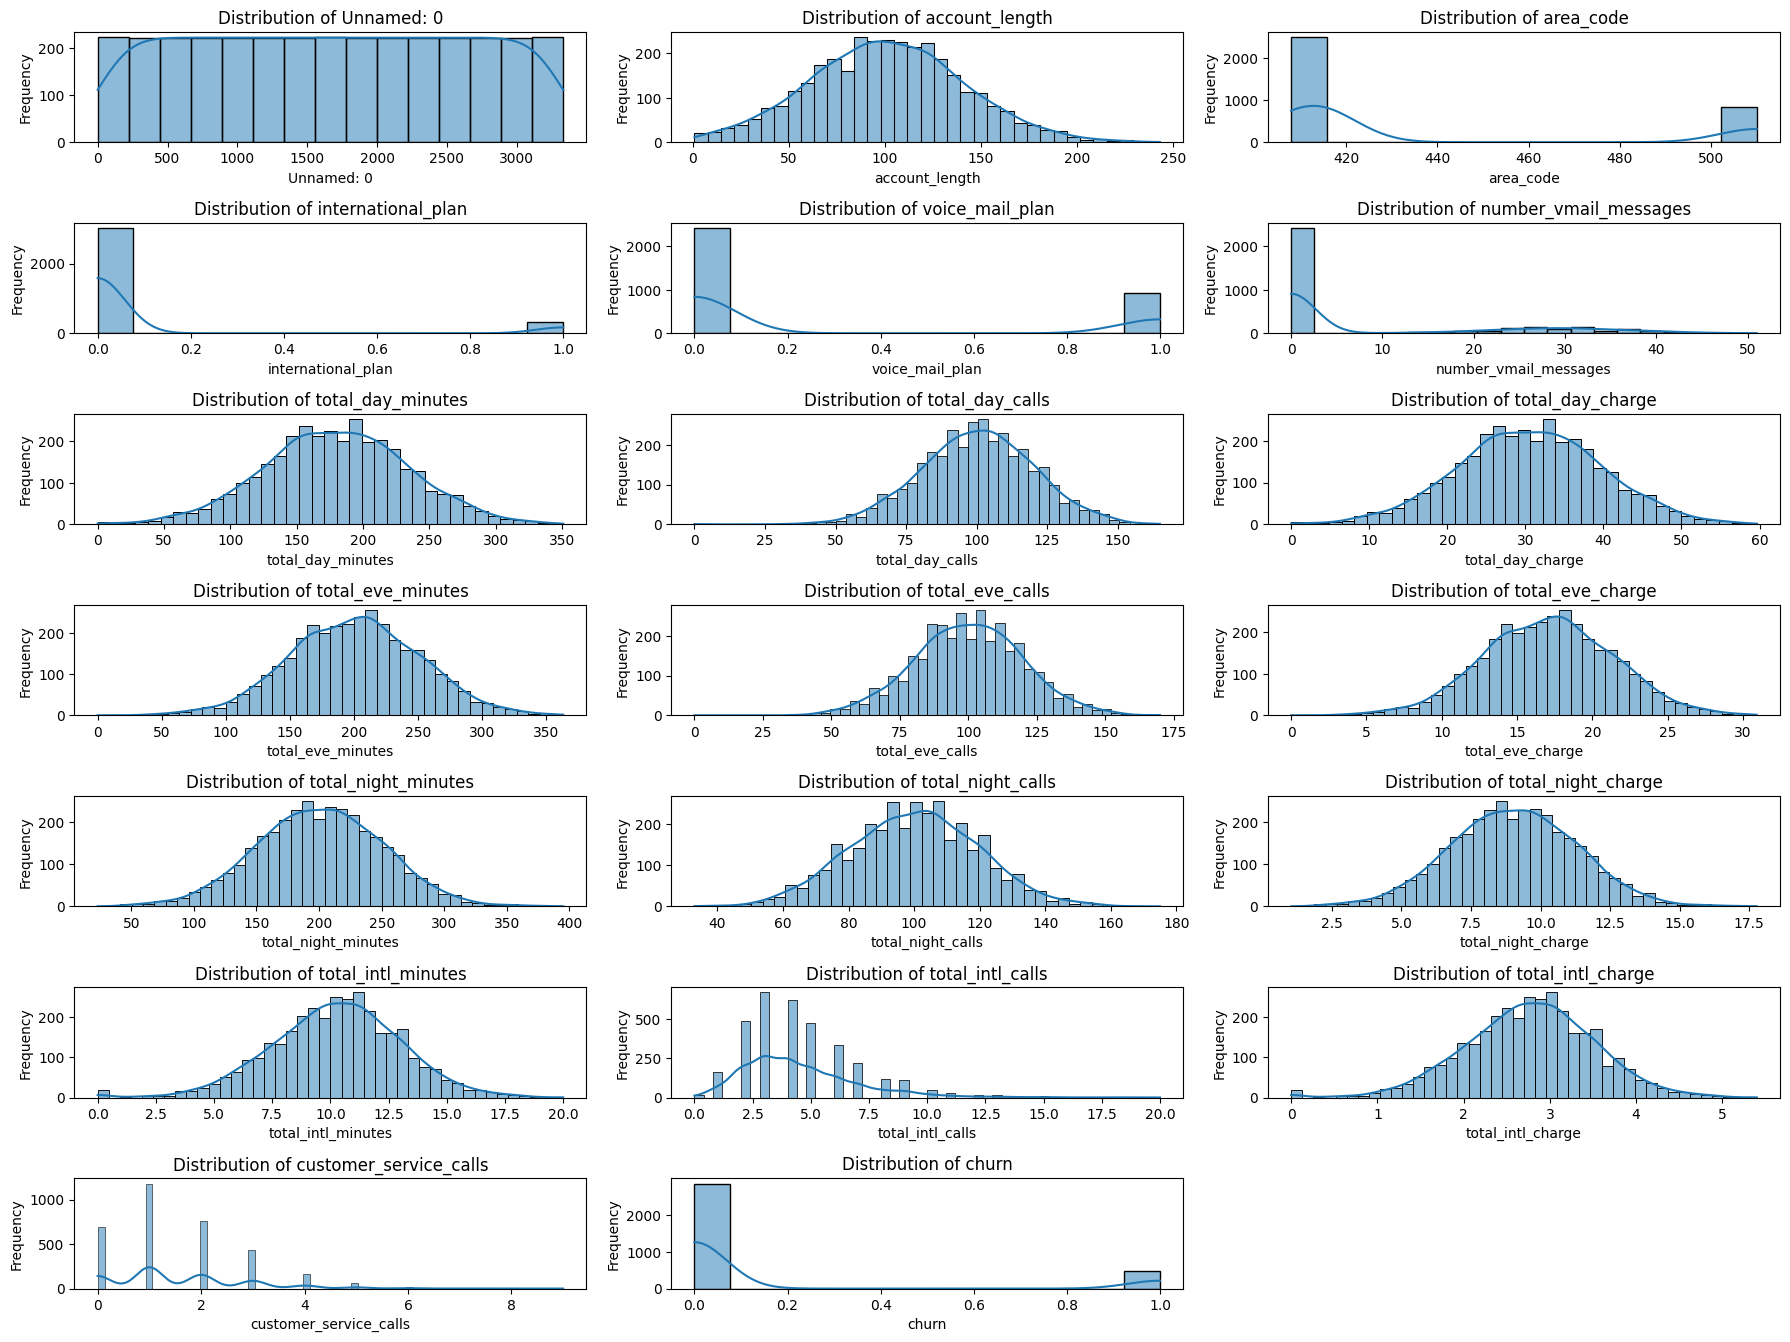

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

print("\n--- Histograms and KDE plots for Numerical Features ---")
# Create histograms and KDE plots for numerical features
plt.figure(figsize=(18, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(round(len(numeric_cols)/3) + 1, 3, i + 1) # Adjust subplot grid dynamically
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Count plots for Categorical Features ---")
# Create count plots for categorical features
if not categorical_cols.empty:
    plt.figure(figsize=(15, 5 * len(categorical_cols)))
    for i, col in enumerate(categorical_cols):
        plt.subplot(len(categorical_cols), 1, i + 1)
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f'Count of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found in the DataFrame.")


--- Count plots for Categorical Features ---
No categorical columns found in the DataFrame.


UNIVARIATE:
Data shows different distributions.
tenure is mostly skewed towards lower values.
understand individual features.





### Bivariate Analysis and EDA: Relationships Between Features


--- Correlation Matrix for Numerical Features ---


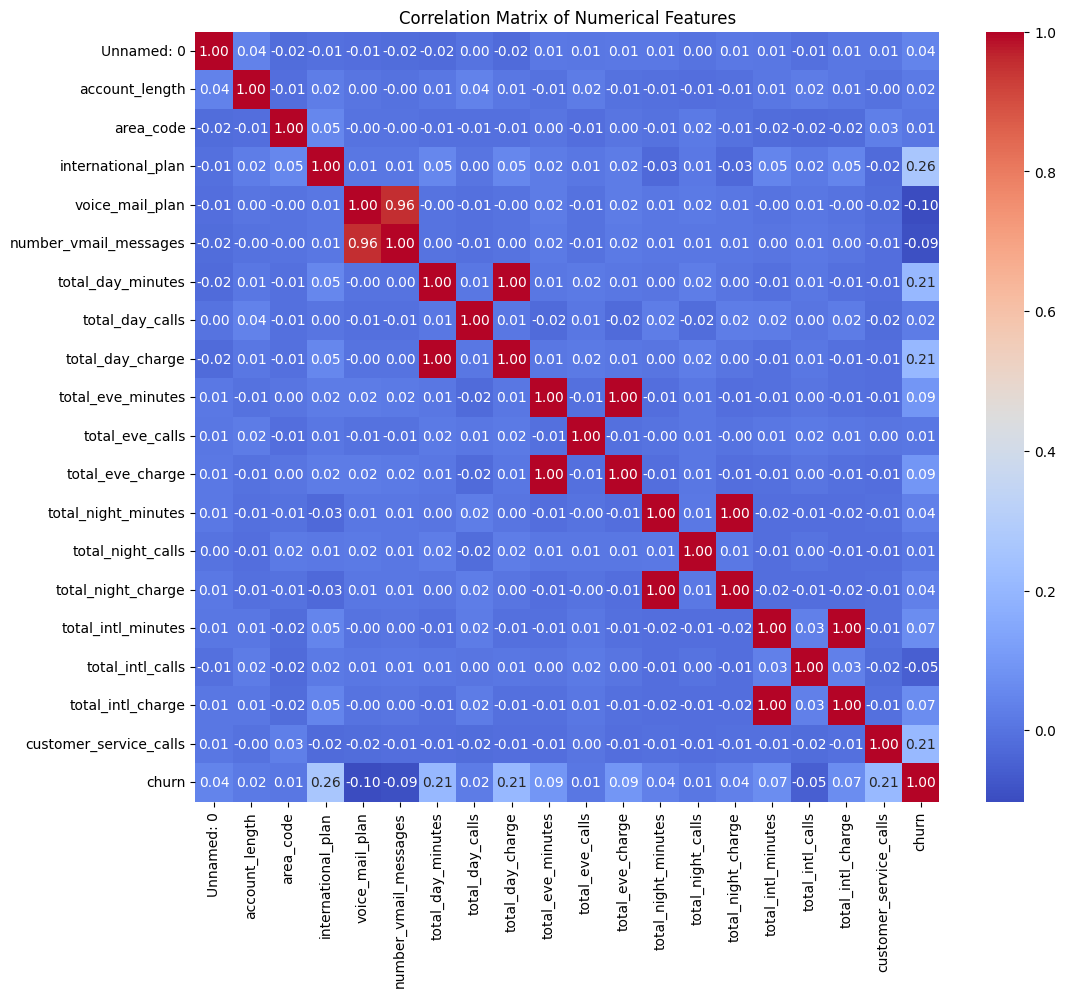

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Matrix for Numerical Features
print("\n--- Correlation Matrix for Numerical Features ---")
plt.figure(figsize=(12, 10))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


--- Box Plots of Numerical Features vs. Churn ---


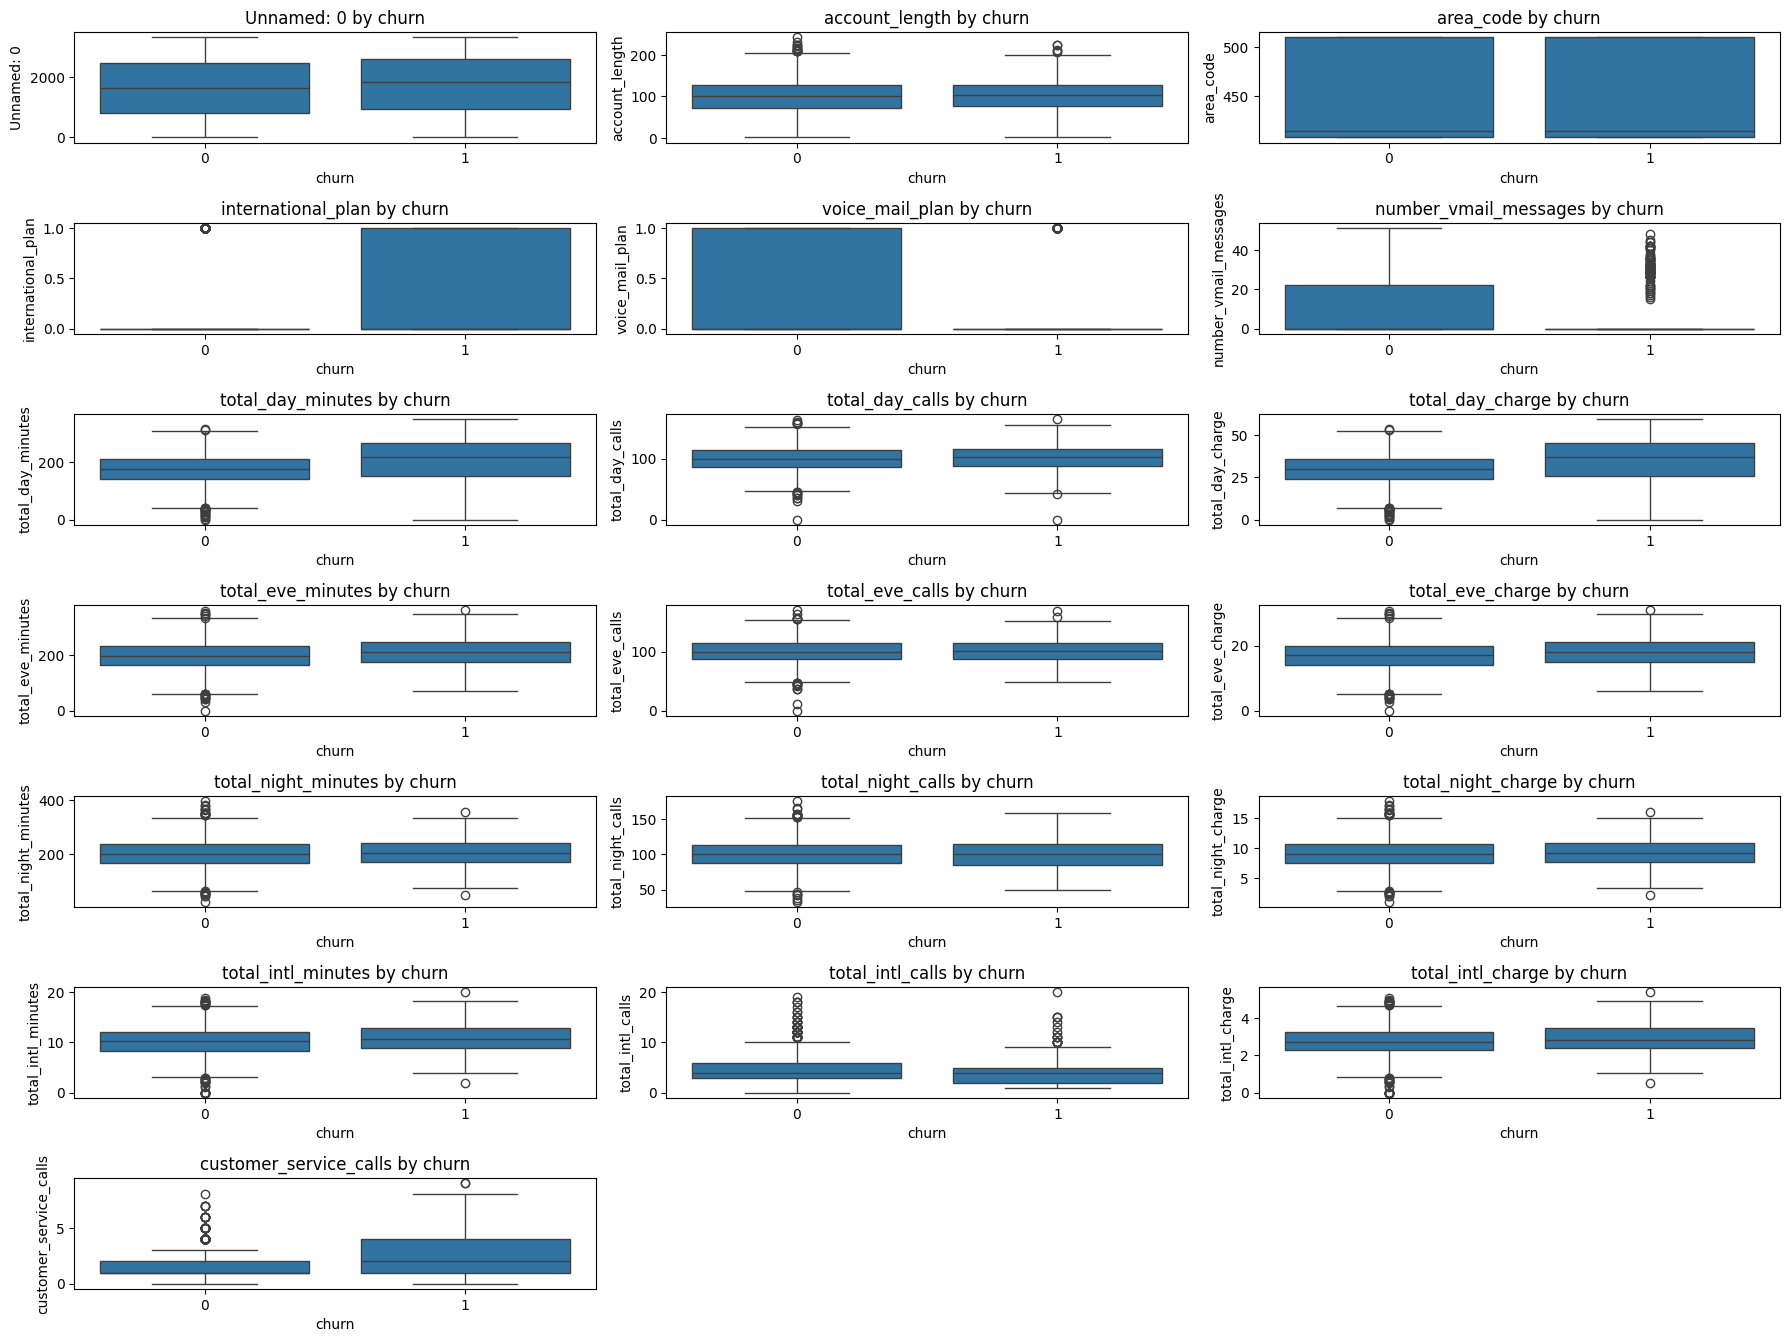

In [ ]:
print("\n--- Box Plots of Numerical Features vs. Churn ---")
# Assume 'churn' is the target variable (binary: 0 or 1)
# If 'churn' is not binary, adjust plot type accordingly

# Ensure 'churn' is treated as categorical for plotting purposes
churn_col_name = 'churn' # You might need to change this if your churn column has a different name

plt.figure(figsize=(18, 15))
for i, col in enumerate(numeric_cols):
    if col != churn_col_name: # Avoid plotting churn against itself
        plt.subplot(round(len(numeric_cols)/3) + 1, 3, i + 1)
        sns.boxplot(x=df[churn_col_name], y=df[col])
        plt.title(f'{col} by {churn_col_name}')
        plt.xlabel(churn_col_name)
        plt.ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Count Plots of Categorical Features vs. Churn ---")

if not categorical_cols.empty:
    plt.figure(figsize=(15, 5 * len(categorical_cols)))
    for i, col in enumerate(categorical_cols):
        if col != churn_col_name: # Avoid plotting churn against itself
            plt.subplot(len(categorical_cols), 1, i + 1)
            sns.countplot(data=df, x=col, hue=churn_col_name, palette='viridis')
            plt.title(f'Count of {col} by {churn_col_name}')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns to plot against churn.")


--- Count Plots of Categorical Features vs. Churn ---
No categorical columns to plot against churn.


BIVARIATE ANALYSIS:
clear variation between churn and non churn
indicates pricing impact on customer behavior
higher monthly charges is linked with more churn